## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes

In [3]:
!pip install scikit-learn
!pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Las imagenes son de tamaño 28x28.
# Pero las imágenes ya vienen desdobladas en vectores (28x28=784)
# Son 70k imágenes

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)


Etiqueta de la imagen: 6


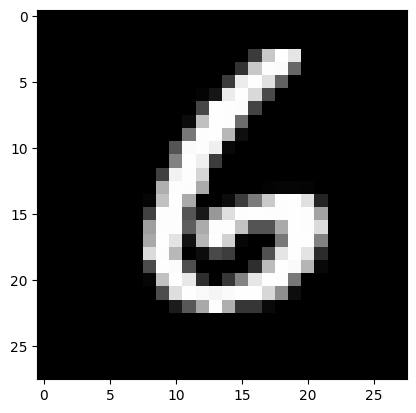

In [3]:
# Por ejemplo, se muestra la imagen 1:

imagen = X[6000].reshape(28,28)
etiqueta = y[6000]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [4]:
# Se seleccionan los grupos de imagenes y etiquetas para el entrenamiento
# y las pruebas. No se debe probar con el mismo grupo de entrenamiento (sesgos).
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)

In [5]:
# Tomo sólo un grupo de datos. Si usamos todos tardará tiempo considerable 
# en el entrenamiento y predicción

X_train = X_train
y_train = y_train

X_test = X_test
y_test = y_test

In [6]:
len(X_train)

56000

In [20]:
# Uso de máquinas de soporte vectorial (SVM) para clasificación

rf = RandomForestClassifier(n_estimators=100, random_state=5,
    n_jobs=-1  # usa todos los núcleos del CPU (acelera)
    ) # Se crea el modelo de Random Forest
rf.fit(X_train, y_train) # Entrenamiento del modelo
y_pred = rf.predict(X_test) # Se obtienen las predicciones con el modelo entrenado

In [21]:
from sklearn.metrics import classification_report

rp = classification_report(y_test, y_pred)
print(rp)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1389
           1       0.98      0.99      0.99      1593
           2       0.96      0.97      0.96      1409
           3       0.96      0.95      0.95      1407
           4       0.97      0.98      0.98      1348
           5       0.97      0.96      0.96      1266
           6       0.98      0.98      0.98      1380
           7       0.97      0.97      0.97      1494
           8       0.95      0.96      0.96      1333
           9       0.96      0.95      0.96      1381

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [ ]:
# 3. FUNCIONES DE PROCESAMIENTO
# ================================

def preprocesar_imagen(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Suavizado
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Umbral adaptativo
    _, thresh = cv2.threshold(blur, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Operaciones morfológicas
    kernel = np.ones((3,3), np.uint8)
    morf = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    return morf


def segmentar_digitos(img_binaria):
    # Componentes conectados
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img_binaria)

    digitos = []

    for i in range(1, num_labels):  # ignorar fondo
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # Filtrar ruido
        if area > 50:
            digito = img_binaria[y:y+h, x:x+w]
            digitos.append((digito, x, y))

    # Ordenar por filas (y) y luego columnas (x)
    digitos = sorted(digitos, key=lambda d: (d[2] // 50, d[1]))

    return [d[0] for d in digitos]

def recortar_bordes(dig):
    # Validar que exista
    if dig is None or dig.size == 0:
        return None

    # Asegurar tipo correcto
    dig = dig.astype(np.uint8)

    coords = cv2.findNonZero(dig)

    # Si no hay píxeles blancos
    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)
    return dig[y:y+h, x:x+w]

def preparar_digito(dig):
    dig = recortar_bordes(dig)

    if dig is None:
        return None

    h, w = dig.shape

    if h == 0 or w == 0:
        return None

    if h > w:
        new_h = 20
        new_w = int(w * (20 / h))
    else:
        new_w = 20
        new_h = int(h * (20 / w))

    dig = cv2.resize(dig, (new_w, new_h))

    canvas = np.zeros((28, 28), dtype=np.uint8)

    x_offset = (28 - new_w) // 2
    y_offset = (28 - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = dig

    return canvas.reshape(1, -1)



<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1032\1074672547.py:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  path = "C:\VisionArtificial\ExU3\img"



Procesando: numeros_01.jpg


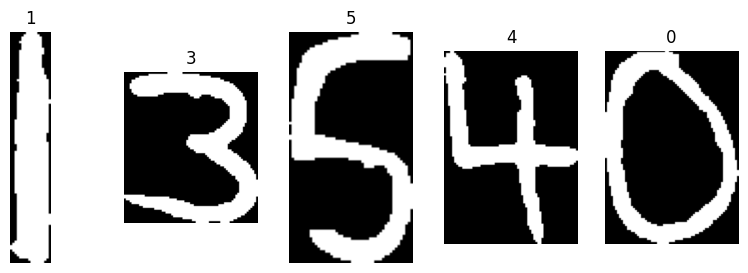

Dígitos detectados: 13540

Procesando: numeros_02.jpeg


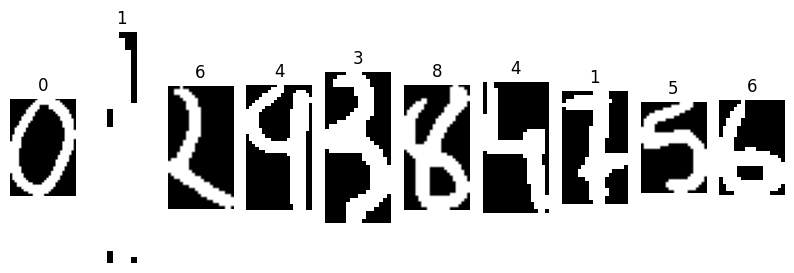

Dígitos detectados: 0164384156

Procesando: numeros_03.jpg


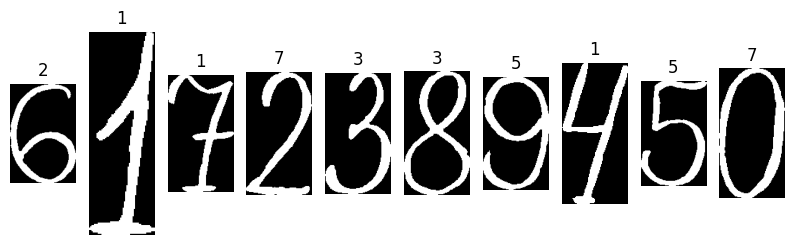

Dígitos detectados: 2117335157


In [30]:

# 4. PROCESAR IMÁGENES DE CARPETA
# ================================

path = "C:\VisionArtificial\ExU3\img"
files = os.listdir(path)

for file in files:
    if not (file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg")):
        continue

    ruta = os.path.join(path, file)
    img = cv2.imread(ruta)

    print(f"\nProcesando: {file}")

    # Preprocesamiento
    img_bin = preprocesar_imagen(img)

    # Segmentación
    digitos = segmentar_digitos(img_bin)

    resultados = []

    plt.figure(figsize=(10,3))

    for i, dig in enumerate(digitos):
        entrada = preparar_digito(dig)

        pred = rf.predict(entrada)[0]
        resultados.append(pred)

        # Mostrar cada dígito
        plt.subplot(1, len(digitos), i+1)
        plt.imshow(dig, cmap='gray')
        plt.title(f"{pred}")
        plt.axis('off')

    plt.show()

    print("Dígitos detectados:", "".join(resultados))